# Kapitel 6 – Stufe 2: Hypothesentestung
**Masterarbeit | Kapitel 6.2**
Autor: Ayumi Nojima | April 2026

---
- **H1** – ANOVA: Unterschiede im Exposure-Index zwischen Hauptgruppen + Sektoral
- **H2** – Random Forest: Fähigkeitsmerkmale als Prädiktoren (**Option B: RF → ΔBFS_j**)
- **H3** – OLS-Regression + **Panel Fixed-Effects 2021–2024** (NEU)

**Hypothesen (vgl. Kap. 4):**
- H1: E_j unterscheidet sich signifikant zwischen CH-ISCO-Hauptgruppen 1–3
- H2: Kognitive/sprachliche Fähigkeiten sind stärkste Prädiktoren
- H3: E_j korreliert mit Beschäftigungsveränderung

**Änderungen gegenüber Vorversion:**
- H2 Option B als Hauptanalyse (RF → ΔBFS_j, zirkulationsfrei)
- H3 Panel Fixed-Effects 2021–2024 ergänzt


## 0. Konfiguration und Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

# ── Pfade ──────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
REPO_ROOT = _cwd.parent if (_cwd / "..").resolve().joinpath("data").exists() else _cwd
if not (REPO_ROOT / "data").exists():
    REPO_ROOT = Path.cwd()

PROCESSED = REPO_ROOT / "data" / "processed"
ANALYSIS  = PROCESSED / "analysis_prep"
INPUT    = REPO_ROOT / "data" / "EDA"
OUTPUT    = REPO_ROOT / "data" / "output"
FIGURES   = OUTPUT / "Hypothesen"
FIGURES.mkdir(parents=True, exist_ok=True)

BFS_BASE_YEAR   = 2022
BFS_TARGET_YEAR = 2024

# ── Daten laden ────────────────────────────────────────────────────────────
final         = pd.read_csv(OUTPUT / "EDA" / "final_sample_clustered.csv")
onet_pivot    = pd.read_csv(PROCESSED / "onet_pivot.csv")

h1 = pd.read_csv(OUTPUT / "dataset_H1.csv")
h2 = pd.read_csv(OUTPUT / "dataset_H2.csv")
h3 = pd.read_csv(OUTPUT / "dataset_H3.csv")

hg_labels = {1: "HG 1 – Führungskräfte", 2: "HG 2 – Akademisch", 3: "HG 3 – Techniker"}
colors     = {1: "#2196F3", 2: "#4CAF50", 3: "#FF9800"}

print(f"H1-Datensatz: {len(h1)} Berufe")
print(f"H2-Datensatz: {len(h2)} Berufe × {h2.shape[1]-2} Prädiktoren")
print(f"H3-Datensatz: {len(h3)} Berufe ({h3['delta_bfs'].notna().sum()} mit ΔBFS_j)")
print("Konfiguration geladen ✓")


H1-Datensatz: 571 Berufe
H2-Datensatz: 571 Berufe × 164 Prädiktoren
H3-Datensatz: 571 Berufe (550 mit ΔBFS_j)
Konfiguration geladen ✓


In [3]:
# ── Aggregation auf ISCO-4-digit-Ebene (für H3) ───────────────────────────
final_isco = (
    final
    .groupby("isco_4digit")
    .agg(
        E_j_mean      = ("E_j",       "mean"),
        E_sub_mean    = ("E_sub_j",   "mean"),
        E_aug_mean    = ("E_aug_j",   "mean"),
        delta_bfs     = ("delta_bfs", "first"),
        is_outlier    = ("is_outlier","first"),
        main_group    = ("main_group","first"),
        n_onet_berufe = ("soc_code",  "count"),
    )
    .reset_index()
)

final_isco_bfs = final_isco.dropna(subset=["delta_bfs"]).copy()
print(f"H3-Analysebasis: {len(final_isco_bfs)} ISCO-4-digit-Berufsgruppen mit ΔBFS_j")
print(final_isco_bfs["main_group"].value_counts().sort_index().to_string())


H3-Analysebasis: 156 ISCO-4-digit-Berufsgruppen mit ΔBFS_j
main_group
1    21
2    77
3    58


---
## H1 – ANOVA: Gruppenunterschiede nach CH-ISCO-Hauptgruppe

**Vorgehen:** Einfaktorielle ANOVA mit E_j als abhängiger Variable und  
Hauptgruppe als Faktor. Bei signifikantem F-Test: Post-hoc Tukey-HSD.  
Voraussetzungsprüfung: Levene-Test (Varianzhomogenität), Shapiro-Wilk (Normalität).


In [4]:
# ── Voraussetzungsprüfung ──────────────────────────────────────────────────
groups = [h1[h1["main_group"] == hg]["E_j"].dropna().values for hg in [1, 2, 3]]

# Levene-Test (Varianzhomogenität)
levene_stat, levene_p = stats.levene(*groups)
print(f"Levene-Test: F={levene_stat:.3f}, p={levene_p:.4f} "
      f"({'✓ Varianzhomogenität' if levene_p > 0.05 else '⚠ Varianzinhomogenität'})")

# Shapiro-Wilk je Gruppe
print("\nShapiro-Wilk Normalitätstest:")
for hg, g in zip([1,2,3], groups):
    stat, p = stats.shapiro(g)
    print(f"  {hg_labels[hg]}: W={stat:.3f}, p={p:.4f} "
          f"({'✓ Normal' if p > 0.05 else '⚠ Nicht normal'})")


Levene-Test: F=39.492, p=0.0000 (⚠ Varianzinhomogenität)

Shapiro-Wilk Normalitätstest:
  HG 1 – Führungskräfte: W=0.571, p=0.0000 (⚠ Nicht normal)
  HG 2 – Akademisch: W=0.923, p=0.0000 (⚠ Nicht normal)
  HG 3 – Techniker: W=0.842, p=0.0000 (⚠ Nicht normal)


In [5]:
# ── Einfaktorielle ANOVA ──────────────────────────────────────────────────
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.3f}, p={p_value:.6f}")
print(f"Ergebnis: {'H1 wird unterstützt – signifikante Gruppenunterschiede' if p_value < 0.05 else 'Kein signifikanter Unterschied'} (α=0.05)")

# Eta-Quadrat (Effektstärke)
grand_mean = np.concatenate(groups).mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total   = sum(((g - grand_mean)**2).sum() for g in groups)
eta_sq     = ss_between / ss_total
print(f"Eta² = {eta_sq:.3f} ({'klein' if eta_sq < 0.06 else 'mittel' if eta_sq < 0.14 else 'gross'})")


ANOVA: F=41.803, p=0.000000
Ergebnis: H1 wird unterstützt – signifikante Gruppenunterschiede (α=0.05)
Eta² = 0.128 (mittel)


In [6]:
# ── Post-hoc: Tukey-HSD ───────────────────────────────────────────────────
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=h1["E_j"].dropna(),
    groups=h1.loc[h1["E_j"].notna(), "main_group"],
    alpha=0.05
)
print("\nTukey-HSD Post-hoc Test:")
print(tukey)



Tukey-HSD Post-hoc Test:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   0.2353    0.0  0.1618  0.3087   True
     1      3   0.0938 0.0107  0.0179  0.1697   True
     2      3  -0.1415    0.0 -0.1887 -0.0942   True
----------------------------------------------------


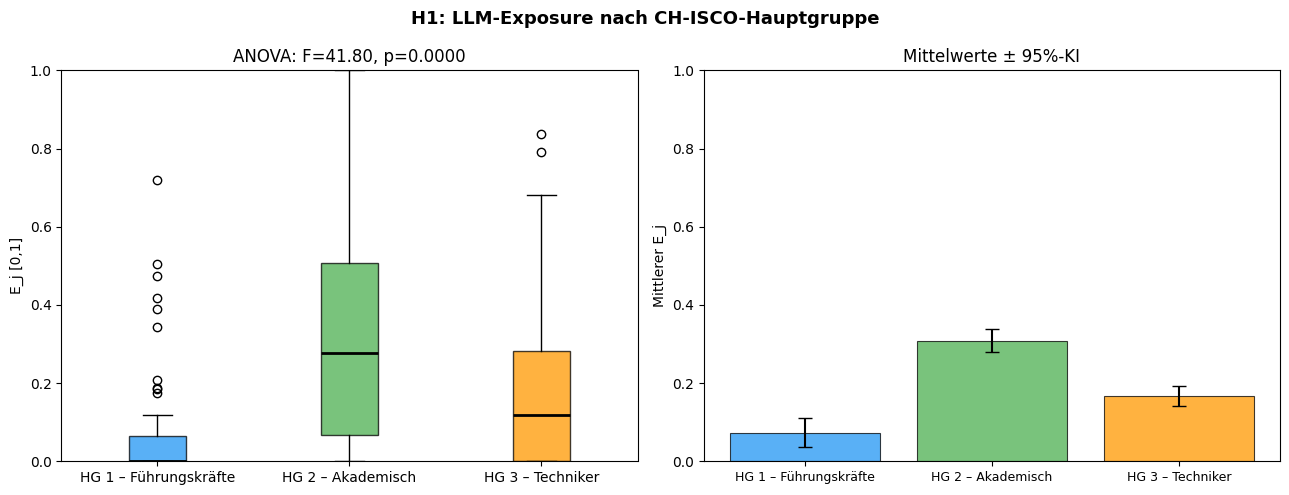

In [7]:
# ── Visualisierung H1 ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("H1: LLM-Exposure nach CH-ISCO-Hauptgruppe", fontsize=13, fontweight="bold")

# Boxplot
data_plot = [h1[h1["main_group"] == hg]["E_j"].dropna() for hg in [1,2,3]]
bp = ax1.boxplot(data_plot, labels=[hg_labels[h] for h in [1,2,3]], patch_artist=True,
                 medianprops={"color": "black", "linewidth": 2})
for patch, hg in zip(bp["boxes"], [1,2,3]):
    patch.set_facecolor(colors[hg]); patch.set_alpha(0.75)
ax1.set_ylabel("E_j [0,1]"); ax1.set_title(f"ANOVA: F={f_stat:.2f}, p={p_value:.4f}")
ax1.set_ylim(0, 1)

# Mittelwerte mit CI
means = [g.mean() for g in data_plot]
cis   = [stats.sem(g) * stats.t.ppf(0.975, len(g)-1) for g in data_plot]
ax2.bar([1,2,3], means, yerr=cis, color=[colors[h] for h in [1,2,3]],
        alpha=0.75, capsize=5, edgecolor="black", linewidth=0.8)
ax2.set_xticks([1,2,3]); ax2.set_xticklabels([hg_labels[h] for h in [1,2,3]], fontsize=9)
ax2.set_ylabel("Mittlerer E_j"); ax2.set_title("Mittelwerte ± 95%-KI"); ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIGURES / "6_2_H1_anova.png", dpi=150, bbox_inches="tight")
plt.show()


---
## H1 Erweiterung – Sektorale Analyse

Vertiefung der Hauptgruppenanalyse: E_j nach Schweizer Branchensegmenten.  
Sektorzuweisung via 2-stelligem ISCO-Präfix (Kläui & Siegenthaler, 2025).


In [8]:
# ── Sektor-Zuweisung via ISCO-4-digit-Präfix ──────────────────────────────
# Quelle: Kläui & Siegenthaler (2025), BFS NOGA-Klassifikation
# Logik: 2-stelliger ISCO-Präfix → Schweizer Branchensegment

SEKTOR_MAP = {
    # ICT & Technik
    "13": "ICT & Technik",   # Führungskräfte ICT
    "25": "ICT & Technik",   # Software, IKT
    "35": "ICT & Technik",   # Techniker IKT
    # Finanz & Beratung
    "12": "Finanz & Beratung",
    "24": "Finanz & Beratung",  # Wirtschaft, Recht, Soziales
    "33": "Finanz & Beratung",  # Finanzfachkräfte
    # Gesundheit & Bildung
    "22": "Gesundheit & Bildung",  # Gesundheitsberufe
    "23": "Gesundheit & Bildung",  # Lehrberufe
    "32": "Gesundheit & Bildung",  # Gesundheitsfachkräfte (mittlere Stufe)
    # Führung & Management
    "11": "Führung & Management",
    "14": "Führung & Management",
    # Ingenieurwesen & Naturwissenschaften
    "21": "Ingenieurwesen & Naturwiss.",
    "31": "Ingenieurwesen & Naturwiss.",
    # Recht, Soziales, Kreativ
    "26": "Recht, Soziales & Kreativ",
    "34": "Recht, Soziales & Kreativ",
}

def assign_sector(isco_4digit):
    prefix = str(isco_4digit)[:2]
    return SEKTOR_MAP.get(prefix, "Sonstiges")

## Sektor auf ISCO-4-digit-Ebene zuweisen
final_isco["sektor"]     = final_isco["isco_4digit"].apply(assign_sector)
final_isco_bfs["sektor"] = final_isco_bfs["isco_4digit"].apply(assign_sector)

# Auch auf O*NET-Ebene verfügbar machen
if "isco_4digit" in final.columns:
    final["sektor"] = final["isco_4digit"].apply(assign_sector)

print("Sektor-Verteilung (ISCO-4-digit-Ebene):")
print(final_isco["sektor"].value_counts().to_string())
print()
print("Sektor-Verteilung (mit ΔBFS_j):")
print(final_isco_bfs["sektor"].value_counts().to_string())

Sektor-Verteilung (ISCO-4-digit-Ebene):
sektor
Ingenieurwesen & Naturwiss.    46
Finanz & Beratung              33
Gesundheit & Bildung           29
Recht, Soziales & Kreativ      27
ICT & Technik                  20
Führung & Management            7

Sektor-Verteilung (mit ΔBFS_j):
sektor
Ingenieurwesen & Naturwiss.    40
Finanz & Beratung              33
Gesundheit & Bildung           29
Recht, Soziales & Kreativ      27
ICT & Technik                  20
Führung & Management            7


### H1 erweitert: ANOVA nach Sektor (Hauptdimension)

In [9]:
import statsmodels.formula.api as smf
from scipy import stats as sp_stats

# ── sektor_stats berechnen (falls nicht aus EDA verfügbar) ────────────────
sektor_stats = (
    final_isco
    .groupby("sektor")
    .agg(
        n          = ("isco_4digit", "count"),
        E_j_mean   = ("E_j_mean",   "mean"),
        E_j_std    = ("E_j_mean",   "std"),
        E_sub_mean = ("E_sub_mean", "mean"),
        E_aug_mean = ("E_aug_mean", "mean"),
    )
    .sort_values("E_j_mean", ascending=False)
    .reset_index()
)

# ── ANOVA: E_j nach Sektor ────────────────────────────────────────────────
valid_sektoren = sektor_stats[sektor_stats["n"] >= 5]["sektor"].tolist()
anova_data = final_isco[final_isco["sektor"].isin(valid_sektoren)].copy()

groups_s = [anova_data[anova_data["sektor"]==s]["E_j_mean"].dropna().values
            for s in valid_sektoren]

f_stat_s, p_val_s = sp_stats.f_oneway(*groups_s)

# Eta²
grand_mean_s = np.concatenate(groups_s).mean()
ss_between_s = sum(len(g)*(g.mean()-grand_mean_s)**2 for g in groups_s)
ss_total_s   = sum(((g-grand_mean_s)**2).sum() for g in groups_s)
eta_sq_s     = ss_between_s / ss_total_s

print(f"ANOVA nach Sektor (n={len(anova_data)} Berufsgruppen, {len(valid_sektoren)} Sektoren):")
print(f"  F={f_stat_s:.3f}, p={p_val_s:.4f}")
print(f"  Eta² = {eta_sq_s:.3f} ({'klein' if eta_sq_s<0.06 else 'mittel' if eta_sq_s<0.14 else 'gross'})")
print()

# Tukey Post-hoc wenn signifikant
if p_val_s < 0.05 and len(valid_sektoren) > 2:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    tukey_s = pairwise_tukeyhsd(
        endog=anova_data["E_j_mean"].dropna(),
        groups=anova_data.loc[anova_data["E_j_mean"].notna(), "sektor"],
        alpha=0.05
    )
    print("Tukey-HSD Post-hoc (nur signifikante Paare):")
    tukey_df = pd.DataFrame(
        data=tukey_s._results_table.data[1:],
        columns=tukey_s._results_table.data[0]
    )
    print(tukey_df[tukey_df["reject"] == True].to_string(index=False))
else:
    print("Kein signifikanter Unterschied zwischen Sektoren (p≥0.05)")

ANOVA nach Sektor (n=162 Berufsgruppen, 6 Sektoren):
  F=4.101, p=0.0016
  Eta² = 0.116 (mittel)

Tukey-HSD Post-hoc (nur signifikante Paare):
              group1                      group2  meandiff  p-adj  lower  upper  reject
Führung & Management Ingenieurwesen & Naturwiss.    0.2682 0.0271 0.0188 0.5176    True
Gesundheit & Bildung Ingenieurwesen & Naturwiss.    0.1564 0.0276 0.0107 0.3021    True


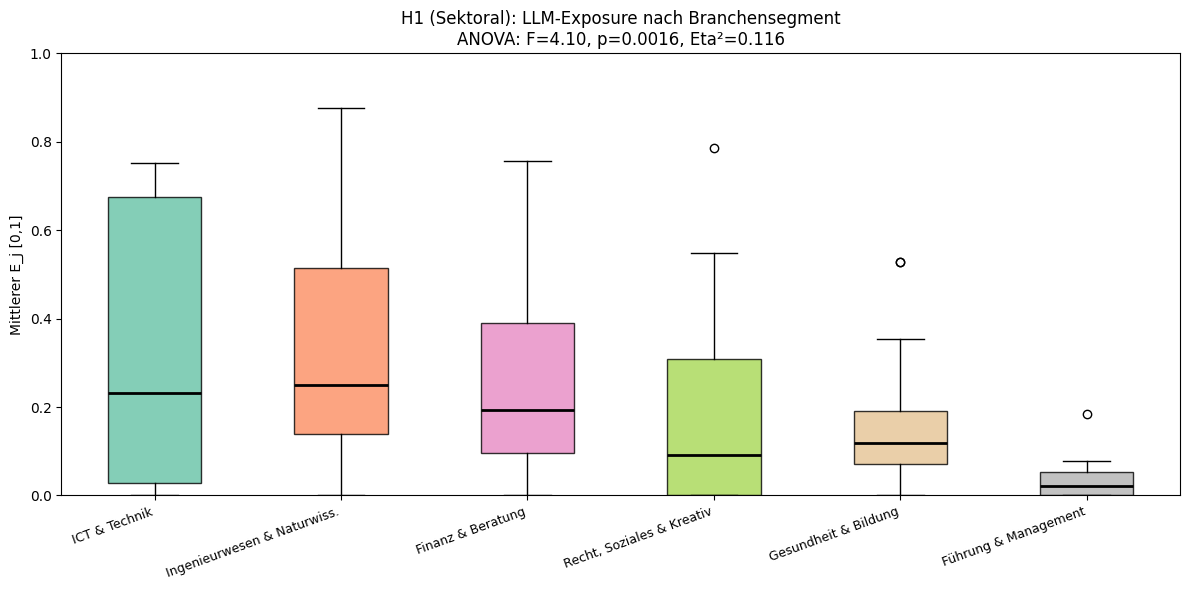

Gespeichert → output/EDA/6_2_H1_sector_anova.png ✓


In [10]:
# ── Boxplot E_j nach Sektor ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

data_s = [anova_data[anova_data["sektor"]==s]["E_j_mean"].dropna().values
          for s in valid_sektoren]
bp = ax.boxplot(data_s, labels=valid_sektoren, patch_artist=True,
                medianprops={"color": "black", "linewidth": 2},
                vert=True)

cmap = plt.cm.Set2(np.linspace(0, 1, len(valid_sektoren)))
for patch, color in zip(bp["boxes"], cmap):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_ylabel("Mittlerer E_j [0,1]")
ax.set_title(
    f"H1 (Sektoral): LLM-Exposure nach Branchensegment\n"
    f"ANOVA: F={f_stat_s:.2f}, p={p_val_s:.4f}, Eta²={eta_sq_s:.3f}",
    fontsize=12
)
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / "6_2_H1_sector_anova.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gespeichert → output/EDA/6_2_H1_sector_anova.png ✓")


---
## H2 – Random Forest: Fähigkeitsprädiktoren → ΔBFS_j (Option B)

**Methodische Begründung für Option B:**
Die ursprüngliche H2-Analyse (RF → E^sub_j) war zirkulär:
E^sub_j wird direkt aus denselben O\*NET-Fähigkeitswerten berechnet wie die Features.
Option B vermeidet diese Zirkularität vollständig: Target ist ΔBFS_j (BFS-Beschäftigungsveränderung),
das methodisch unabhängig von den O\*NET-Fähigkeitsprofilen ist.

**Vorgehen:** RF Regressor mit 5-facher CV auf ISCO-4-digit-Ebene.
Erwartetes CV R² ist niedrig (konsistent mit H3-Nullbefund / Adoptionslücke).
Feature Importance zeigt welche Fähigkeiten mit realen Beschäftigungseffekten korrelieren.


In [11]:
# ── H2 Option B: Datenvorbereitung auf ISCO-Ebene ────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance

# h2 enthält neu: isco_4digit, delta_bfs, is_outlier + alle Fähigkeitsspalten
# (ergänzt in Notebook 02)
feature_cols_all = [c for c in h2.columns
                    if c not in ["soc_code", "isco_4digit", "E_sub_j",
                                  "delta_bfs", "is_outlier"]]

# Aggregation auf ISCO-4-digit-Ebene
h2_mit_isco = h2.copy()
h2_mit_isco["isco_4digit"] = h2_mit_isco["isco_4digit"].astype(str)

skill_isco = (
    h2_mit_isco.groupby("isco_4digit")[feature_cols_all]
    .mean()
    .reset_index()
)

# ΔBFS_j als Target
final_isco_bfs["isco_4digit"] = final_isco_bfs["isco_4digit"].astype(str)
skill_isco = skill_isco.merge(
    final_isco_bfs[["isco_4digit", "delta_bfs", "is_outlier"]],
    on="isco_4digit", how="inner"
)
skill_isco_clean = skill_isco[
    ~skill_isco["is_outlier"].astype(str).isin(["True","1","1.0"])
].copy()

X_b = skill_isco_clean[feature_cols_all].fillna(0).values
y_b = skill_isco_clean["delta_bfs"].values

print(f"H2 Option B: {X_b.shape[0]} ISCO-Codes × {X_b.shape[1]} Fähigkeitsdimensionen")
print(f"ΔBFS_j: Mean={y_b.mean():.1f}% | Std={y_b.std():.1f}%")


H2 Option B: 148 ISCO-Codes × 161 Fähigkeitsdimensionen
ΔBFS_j: Mean=4.0% | Std=12.5%


In [12]:
# ── RF Training + CV ─────────────────────────────────────────────────────
rf_b = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
n_folds = 3 if len(y_b) < 60 else 5
cv_scores_b = cross_val_score(rf_b, X_b, y_b, cv=n_folds, scoring="r2")
rf_b.fit(X_b, y_b)

print(f"{n_folds}-fache CV R²: {cv_scores_b.mean():.3f} ± {cv_scores_b.std():.3f}")
print(f"CV-Scores: {cv_scores_b.round(3)}")
print(f"In-Sample R²: {rf_b.score(X_b, y_b):.3f}")
print()
if cv_scores_b.mean() > 0.10:
    print("✓ Positives CV-R²: Fähigkeitsprofile haben Vorhersagekraft für ΔBFS_j")
elif cv_scores_b.mean() > 0:
    print("~ Schwaches CV-R²: Konsistent mit Adoptionslücke (Humlum & Vestergaard 2025)")
else:
    print("⚠ Negatives CV-R²: Fähigkeitsprofile erklären ΔBFS_j nicht besser als Mittelwert")
    print("  → Adoptionslücke dominiert — technisches Potential ≠ realer Beschäftigungseffekt")


5-fache CV R²: -0.088 ± 0.053
CV-Scores: [-0.104 -0.117 -0.077 -0.149  0.006]
In-Sample R²: 0.449

⚠ Negatives CV-R²: Fähigkeitsprofile erklären ΔBFS_j nicht besser als Mittelwert
  → Adoptionslücke dominiert — technisches Potential ≠ realer Beschäftigungseffekt


In [13]:
# ── Permutation Importance ────────────────────────────────────────────────
perm_b = permutation_importance(
    rf_b, X_b, y_b,
    n_repeats=50,
    random_state=42,
    n_jobs=-1
)
importance_b = pd.DataFrame({
    "feature":    feature_cols_all,
    "importance": perm_b.importances_mean,
    "std":        perm_b.importances_std,
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_b_pos = importance_b[importance_b["importance"] > 0]
print(f"Dimensionen mit positiver Importance: {len(importance_b_pos)} von {len(importance_b)}")
print()
print("=== Top-15 Prädiktoren für ΔBFS_j ===")
print(importance_b.head(15)[["feature","importance","std"]].round(4).to_string(index=False))

importance_b.to_csv(FIGURES / "H2_feature_importance.csv", index=False)
print("\nGespeichert → H2_feature_importance.csv ✓")


Dimensionen mit positiver Importance: 161 von 161

=== Top-15 Prädiktoren für ΔBFS_j ===
                                                                 feature  importance    std
                                Work Activities – Working with Computers      0.0147 0.0035
                                                   Knowledge – Fine Arts      0.0132 0.0025
                                         Knowledge – Sales and Marketing      0.0126 0.0025
                                          Knowledge – Telecommunications      0.0116 0.0027
                                   Knowledge – Production and Processing      0.0112 0.0025
                  Work Activities – Developing Objectives and Strategies      0.0110 0.0024
                                                    Skills – Mathematics      0.0103 0.0021
Work Activities – Communicating with Supervisors, Peers, or Subordinates      0.0097 0.0020
                                                    Skills – Programming      0.009

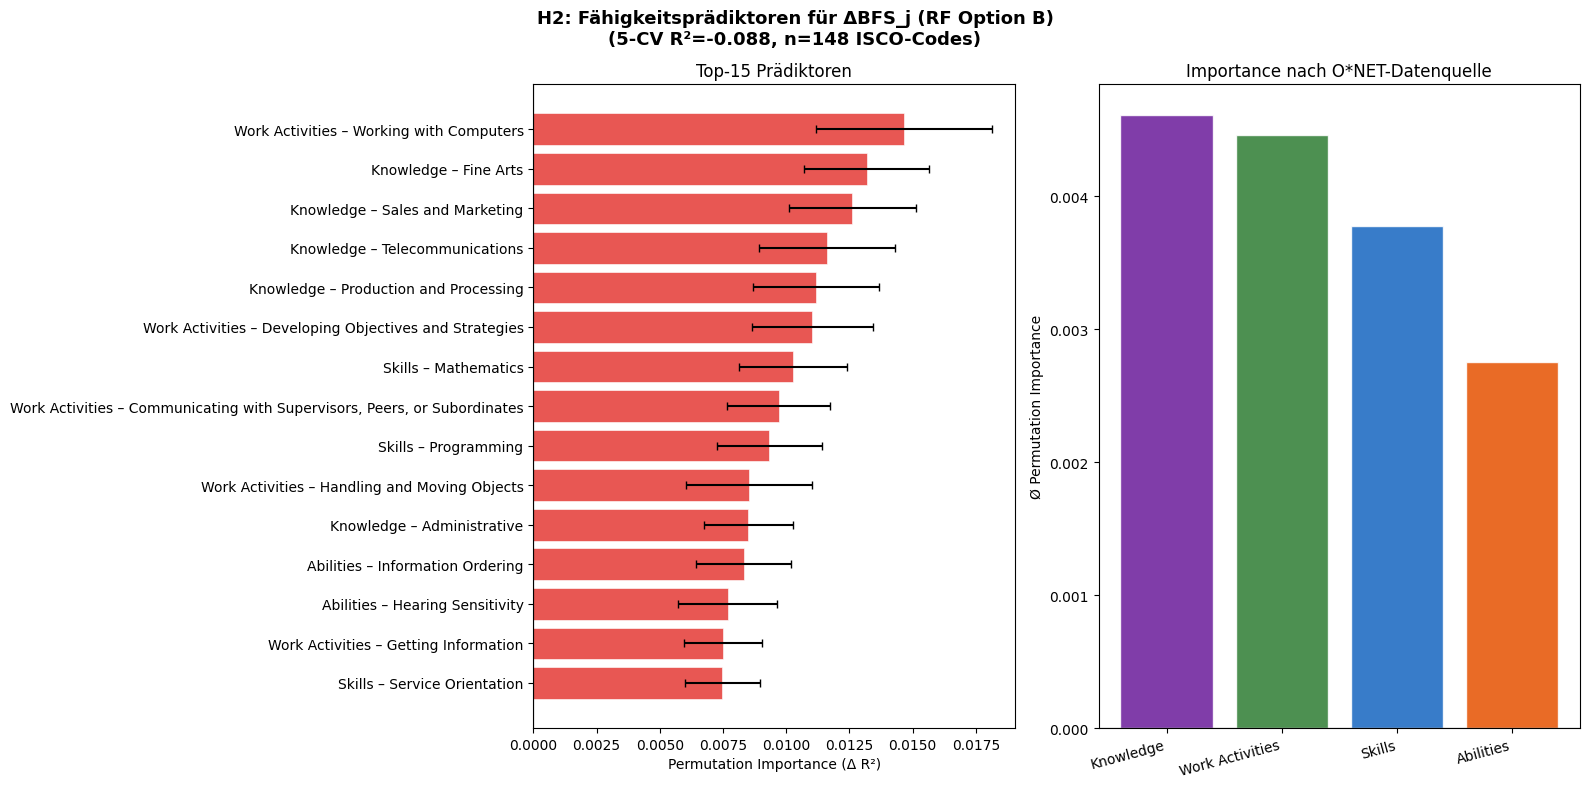

Gespeichert → 6_2_H2_feature_importance.png ✓


In [14]:
# ── Visualisierung H2 Option B ────────────────────────────────────────────
top15 = importance_b.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle(
    f"H2: Fähigkeitsprädiktoren für ΔBFS_j (RF Option B)\n"
    f"({n_folds}-CV R²={cv_scores_b.mean():.3f}, n={len(y_b)} ISCO-Codes)",
    fontsize=13, fontweight="bold"
)

# Top-15 Importance
ax = axes[0]
bar_colors_b = ["#E53935" if imp > 0.005 else "#43A047" if imp > 0 else "#90A4AE"
                for imp in top15["importance"]]
ax.barh(top15["feature"], top15["importance"],
        xerr=top15["std"], color=bar_colors_b,
        alpha=0.85, capsize=3, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Permutation Importance (Δ R²)")
ax.set_title("Top-15 Prädiktoren")
ax.invert_yaxis()

# Importance nach O*NET-Quelle
ax = axes[1]
importance_b["source"] = importance_b["feature"].str.split(" – ").str[0]
source_imp = (
    importance_b.groupby("source")["importance"]
    .agg(["mean","sum","count"])
    .reset_index()
    .sort_values("mean", ascending=False)
)
source_colors = {"Skills":"#1565C0","Abilities":"#E65100",
                 "Work Activities":"#2E7D32","Knowledge":"#6A1B9A"}
bar_cols_src = [source_colors.get(s,"#90A4AE") for s in source_imp["source"]]
ax.bar(source_imp["source"], source_imp["mean"],
       color=bar_cols_src, alpha=0.85, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Ø Permutation Importance")
ax.set_title("Importance nach O*NET-Datenquelle")
ax.set_xticklabels(source_imp["source"], rotation=15, ha="right")

plt.tight_layout()
plt.savefig(FIGURES / "6_2_H2_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gespeichert → 6_2_H2_feature_importance.png ✓")


---
## H3 – OLS-Regression: E_j und ΔBFS_j

**Vorgehen:** OLS-Regression mit ΔBFS_j als abhängiger Variable und E_j sowie  
Kontrollvariablen (Hauptgruppe, Qualifikationsniveau) als Prädiktoren.  
Robustheitsprüfung: Regression ohne Ausreisser (IQR-geflaggt).  
Quelle: Kläui & Siegenthaler (2025) als Orientierung für Effektgrössen.


In [15]:
# ── H3 Datenvorbereitung – ISCO-4-digit-Ebene ────────────────────────────
import statsmodels.formula.api as smf
from scipy import stats as sp_stats

# is_outlier sicher als Boolean konvertieren
final_isco_bfs["is_outlier"] = final_isco_bfs["is_outlier"].astype(str).isin(["True", "1", "1.0"])

# Hauptanalyse: ohne Ausreisser
h3_main = final_isco_bfs[~final_isco_bfs["is_outlier"]].copy()
h3_main["main_group"] = h3_main["main_group"].astype(int)

print(f"H3 Hauptanalyse:    {len(h3_main)} Berufsgruppen (ohne Ausreisser)")
print(f"H3 Robustheit:      {len(final_isco_bfs)} Berufsgruppen (inkl. Ausreisser)")
print(f"E_j_mean: {h3_main['E_j_mean'].describe()[['mean','std','min','max']].round(3).to_string()}")
print(f"delta_bfs: {h3_main['delta_bfs'].describe()[['mean','std','min','max']].round(3).to_string()}")

H3 Hauptanalyse:    148 Berufsgruppen (ohne Ausreisser)
H3 Robustheit:      156 Berufsgruppen (inkl. Ausreisser)
E_j_mean: mean    0.244
std     0.226
min     0.000
max     0.876
delta_bfs: mean     3.999
std     12.537
min    -25.657
max     37.403


In [16]:
# ── Modell 1: Bivariat E_j → ΔBFS_j ──────────────────────────────────────
model1 = smf.ols("delta_bfs ~ E_j_mean", data=h3_main).fit(cov_type="HC3")
print("=== Modell 1: Bivariat (ohne Ausreisser, ISCO-Ebene) ===")
print(model1.summary2().tables[1].round(3))
print(f"R²={model1.rsquared:.3f} | Adj. R²={model1.rsquared_adj:.3f} | N={int(model1.nobs)}")


=== Modell 1: Bivariat (ohne Ausreisser, ISCO-Ebene) ===
           Coef.  Std.Err.      z  P>|z|  [0.025  0.975]
Intercept  1.686     1.454  1.159  0.246  -1.164   4.535
E_j_mean   9.482     4.560  2.079  0.038   0.544  18.419
R²=0.029 | Adj. R²=0.023 | N=148


In [17]:
# ── Modell 2: Mit Hauptgruppen-Kontrolle ──────────────────────────────────
model2 = smf.ols(
    "delta_bfs ~ E_j_mean + C(main_group, Treatment(2))",
    data=h3_main
).fit(cov_type="HC3")
print("=== Modell 2: Mit Hauptgruppen-Kontrolle ===")
print(model2.summary2().tables[1].round(3))
print(f"R²={model2.rsquared:.3f} | Adj. R²={model2.rsquared_adj:.3f} | N={int(model2.nobs)}")


=== Modell 2: Mit Hauptgruppen-Kontrolle ===
                                  Coef.  Std.Err.      z  P>|z|  [0.025  \
Intercept                         3.277     1.998  1.640  0.101  -0.639   
C(main_group, Treatment(2))[T.1] -3.734     2.924 -1.277  0.202  -9.465   
C(main_group, Treatment(2))[T.3] -1.376     2.316 -0.594  0.552  -5.915   
E_j_mean                          7.124     4.787  1.488  0.137  -2.259   

                                  0.975]  
Intercept                          7.193  
C(main_group, Treatment(2))[T.1]   1.996  
C(main_group, Treatment(2))[T.3]   3.163  
E_j_mean                          16.508  
R²=0.037 | Adj. R²=0.017 | N=148


In [18]:
# ── Modell-Vergleich ───────────────────────────────────────────────────────
model_robust = smf.ols(
    "delta_bfs ~ E_j_mean + C(main_group, Treatment(2))",
    data=final_isco_bfs
).fit(cov_type="HC3")

comparison = pd.DataFrame({
    "Modell":       ["M1: Bivariat", "M2: + Hauptgruppe", "M_robust: inkl. Ausreisser"],
    "N":            [int(model1.nobs), int(model2.nobs), int(model_robust.nobs)],
    "R²":           [model1.rsquared, model2.rsquared, model_robust.rsquared],
    "Adj. R²":      [model1.rsquared_adj, model2.rsquared_adj, model_robust.rsquared_adj],
    "β E_j":        [model1.params["E_j_mean"], model2.params["E_j_mean"], model_robust.params["E_j_mean"]],
    "p E_j":        [model1.pvalues["E_j_mean"], model2.pvalues["E_j_mean"], model_robust.pvalues["E_j_mean"]],
}).round(4)
print(comparison.to_string(index=False))

# Speichern
comparison.to_csv(FIGURES / "H3_regression_results.csv", index=False)
print("\nGespeichert → data/processed/analysis_prep/H3_regression_results.csv ✓")


                    Modell   N     R²  Adj. R²  β E_j  p E_j
              M1: Bivariat 148 0.0292   0.0225 9.4819 0.0376
         M2: + Hauptgruppe 148 0.0373   0.0173 7.1244 0.1367
M_robust: inkl. Ausreisser 156 0.0092  -0.0104 6.3416 0.2836

Gespeichert → data/processed/analysis_prep/H3_regression_results.csv ✓


In [19]:
# ── Robustheitsprüfung: inkl. Ausreisser ──────────────────────────────────
# final_isco_bfs enthält alle Berufsgruppen inkl. Ausreisser
h3_robust = final_isco_bfs.copy()
h3_robust["main_group"] = h3_robust["main_group"].astype(int)

model_robust = smf.ols(
    "delta_bfs ~ E_j_mean + C(main_group, Treatment(2))",
    data=h3_robust
).fit(cov_type="HC3")

print("=== Robustheitsprüfung: Alle Berufe inkl. Ausreisser ===")
print(f"E_j: β={model_robust.params['E_j_mean']:.3f}, p={model_robust.pvalues['E_j_mean']:.4f}")
print(f"R²={model_robust.rsquared:.3f} (vs. {model2.rsquared:.3f} ohne Ausreisser)")

=== Robustheitsprüfung: Alle Berufe inkl. Ausreisser ===
E_j: β=6.342, p=0.2836
R²=0.009 (vs. 0.037 ohne Ausreisser)


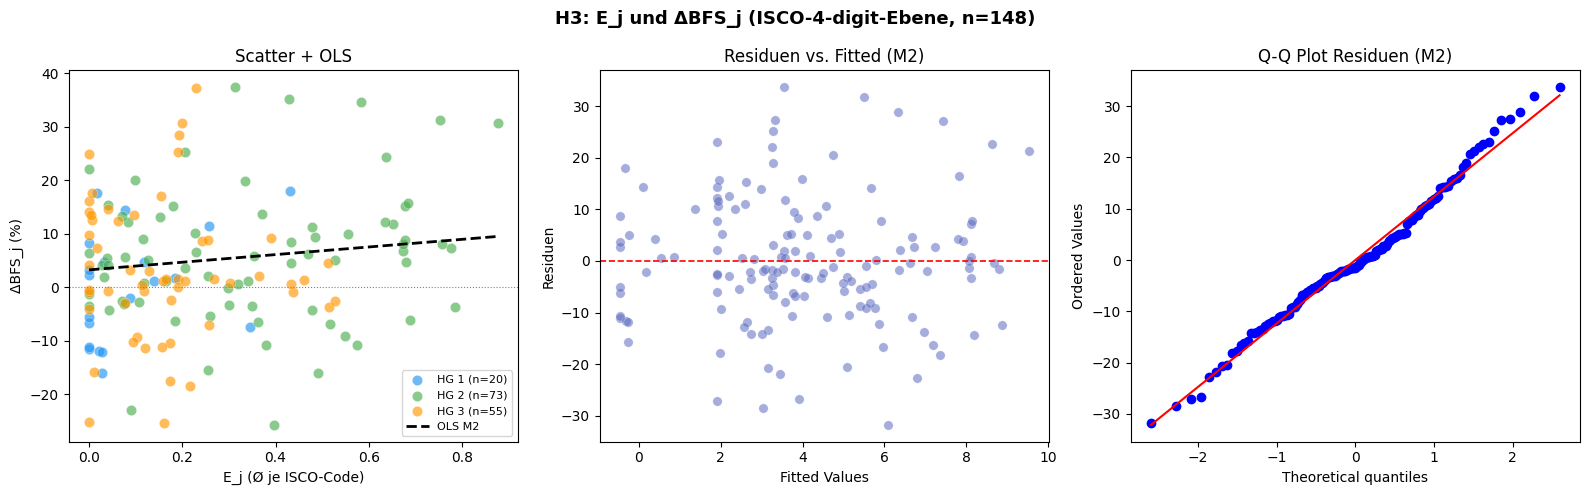

Abbildung gespeichert → output/EDA/6_2_H3_regression.png ✓


In [20]:
# ── Visualisierung H3 ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f"H3: E_j und ΔBFS_j (ISCO-4-digit-Ebene, n={len(h3_main)})",
    fontsize=13, fontweight="bold"
)

colors_h3 = {1: "#2196F3", 2: "#4CAF50", 3: "#FF9800"}

# Scatter + Regressionslinie
ax = axes[0]
for hg in sorted(h3_main["main_group"].unique()):
    s = h3_main[h3_main["main_group"] == hg]
    ax.scatter(s["E_j_mean"], s["delta_bfs"],
               color=colors_h3.get(hg, "gray"), alpha=0.65, s=55,
               label=f"HG {hg} (n={len(s)})", edgecolors="white", linewidth=0.3)

x_pred = np.linspace(h3_main["E_j_mean"].min(), h3_main["E_j_mean"].max(), 100)
y_pred = model2.params["Intercept"] + model2.params["E_j_mean"] * x_pred
ax.plot(x_pred, y_pred, "k--", linewidth=2, label="OLS M2")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("E_j (Ø je ISCO-Code)")
ax.set_ylabel("ΔBFS_j (%)")
ax.set_title("Scatter + OLS")
ax.legend(fontsize=8)

# Residuen vs. Fitted
ax = axes[1]
ax.scatter(model2.fittedvalues, model2.resid,
           alpha=0.55, s=45, color="#5C6BC0", edgecolors="white", linewidth=0.3)
ax.axhline(0, color="red", linewidth=1.2, linestyle="--")
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuen")
ax.set_title("Residuen vs. Fitted (M2)")

# Q-Q Plot
ax = axes[2]
sp_stats.probplot(model2.resid, dist="norm", plot=ax)
ax.set_title("Q-Q Plot Residuen (M2)")

plt.tight_layout()
plt.savefig(FIGURES / "6_2_H3_regression.png", dpi=150, bbox_inches="tight")
plt.show()
print("Abbildung gespeichert → output/EDA/6_2_H3_regression.png ✓")


---
## H3 Erweiterung – Panel Fixed-Effects 2021–2024 (Prio 2)

**Methodische Stärke gegenüber einfacher OLS:**
- Drei Jahresschritte statt zwei Datenpunkte
- Fixed Effects auf ISCO-Ebene partialisieren berufsgruppen-spezifische Basistrends heraus
- Post-KI Dummy (0 = 2021→2022, 1 = 2022→2023 und 2023→2024) testet ob E_j-Effekt nach Nov. 2022 stärker wird
- Methodisch analog Kläui & Siegenthaler (2025)

**Interpretation des Interaktionsterms E_j × post_ki:**
- Positiv signifikant → hoch-exponierte Berufe verschlechtern sich nach 2022 relativ stärker
- Nicht signifikant → Adoptionslücke: kein messbarer Strukturbruch nach ChatGPT-Einführung


In [21]:
# ── Panel Fixed-Effects H3 ────────────────────────────────────────────────
try:
    import linearmodels as lm
    HAS_LINEARMODELS = True
except ImportError:
    HAS_LINEARMODELS = False
    print("linearmodels nicht installiert — verwende OLS mit Clustered SE als Alternative")

# Panel-Datensatz laden (erstellt von Notebook 02)
h3_panel = pd.read_csv(OUTPUT / "dataset_H3_panel.csv",
                        dtype={"ch_isco_4digit": str})
h3_panel["isco_4digit"] = h3_panel["ch_isco_4digit"]

print(f"Panel-Sample: {len(h3_panel)} Beobachtungen")
print(f"  ISCO-Codes: {h3_panel['isco_4digit'].nunique()}")
print(f"  Perioden:   {h3_panel['periode'].unique().tolist()}")
print(f"  Vor-KI  (post=0): {(h3_panel['post_ki']==0).sum()}")
print(f"  Nach-KI (post=1): {(h3_panel['post_ki']==1).sum()}")
print()
print("Deskriptiv nach Periode:")
print(h3_panel.groupby("periode")["delta_bfs"].agg(["mean","std","count"]).round(2).to_string())


linearmodels nicht installiert — verwende OLS mit Clustered SE als Alternative
Panel-Sample: 465 Beobachtungen
  ISCO-Codes: 155
  Perioden:   ['2021_2022', '2022_2023', '2023_2024']
  Vor-KI  (post=0): 155
  Nach-KI (post=1): 310

Deskriptiv nach Periode:
           mean    std  count
periode                      
2021_2022  4.73  16.92    155
2022_2023  5.25  20.03    155
2023_2024  1.40  15.51    155


In [22]:
# ── Panel-Modell: E_j × post_ki Interaktion ──────────────────────────────
# Interaktionsterm: β_DiD = E_j × post_ki
# Interpretation: stärkerer/schwächerer E_j-Effekt nach ChatGPT-Einführung?
h3_panel["E_j_x_post"] = h3_panel["E_j_mean"] * h3_panel["post_ki"]

if HAS_LINEARMODELS:
    # Fixed Effects Panel-Modell (Berufsgruppen-FE absorbiert zeitinvariante Unterschiede)
    panel_data = h3_panel.set_index(["isco_4digit", "periode"])
    model_fe = lm.PanelOLS(
        dependent=panel_data["delta_bfs"],
        exog=sm.add_constant(panel_data[["E_j_mean", "post_ki", "E_j_x_post"]]),
        entity_effects=True
    ).fit(cov_type="clustered", cluster_entity=True)
    print("=== Fixed Effects Panel-Modell ===")
    print(model_fe.summary.tables[1])
    beta_panel = model_fe.params.get("E_j_x_post", None)
    p_panel    = model_fe.pvalues.get("E_j_x_post", None)
else:
    # Fallback: Pooled OLS mit Interaktion (weniger stark, aber verfügbar)
    model_fe = smf.ols(
        "delta_bfs ~ E_j_mean + post_ki + E_j_x_post + C(isco_4digit)",
        data=h3_panel
    ).fit(cov_type="HC3")
    print("=== Pooled OLS mit ISCO-Dummies (Fallback) ===")
    print(f"R²={model_fe.rsquared:.3f} | N={int(model_fe.nobs)}")
    beta_panel = model_fe.params.get("E_j_x_post", None)
    p_panel    = model_fe.pvalues.get("E_j_x_post", None)

if beta_panel is not None:
    print(f"\nβ_DiD (E_j × post_ki) = {beta_panel:.3f} (p={p_panel:.4f})")
    if p_panel < 0.05 and beta_panel < 0:
        print("✓ Signifikant negativ: Nach 2022 stärkerer Beschäftigungsrückgang in hoch-exponierten Berufen")
        print("  Konsistent mit KI-Displacement-Effekt (Kläui & Siegenthaler, 2025)")
    elif p_panel < 0.05 and beta_panel > 0:
        print("~ Signifikant positiv: Hoch-exponierte Berufe wachsen nach 2022 stärker")
        print("  Konsistent mit Augmentations-Hypothese")
    else:
        print("~ Nicht signifikant: Kein messbarer Strukturbruch nach Nov. 2022")
        print("  Adoptionslücke dominiert — Humlum & Vestergaard (2025) repliziert")


=== Pooled OLS mit ISCO-Dummies (Fallback) ===
R²=0.168 | N=465

β_DiD (E_j × post_ki) = -18.073 (p=0.1221)
~ Nicht signifikant: Kein messbarer Strukturbruch nach Nov. 2022
  Adoptionslücke dominiert — Humlum & Vestergaard (2025) repliziert


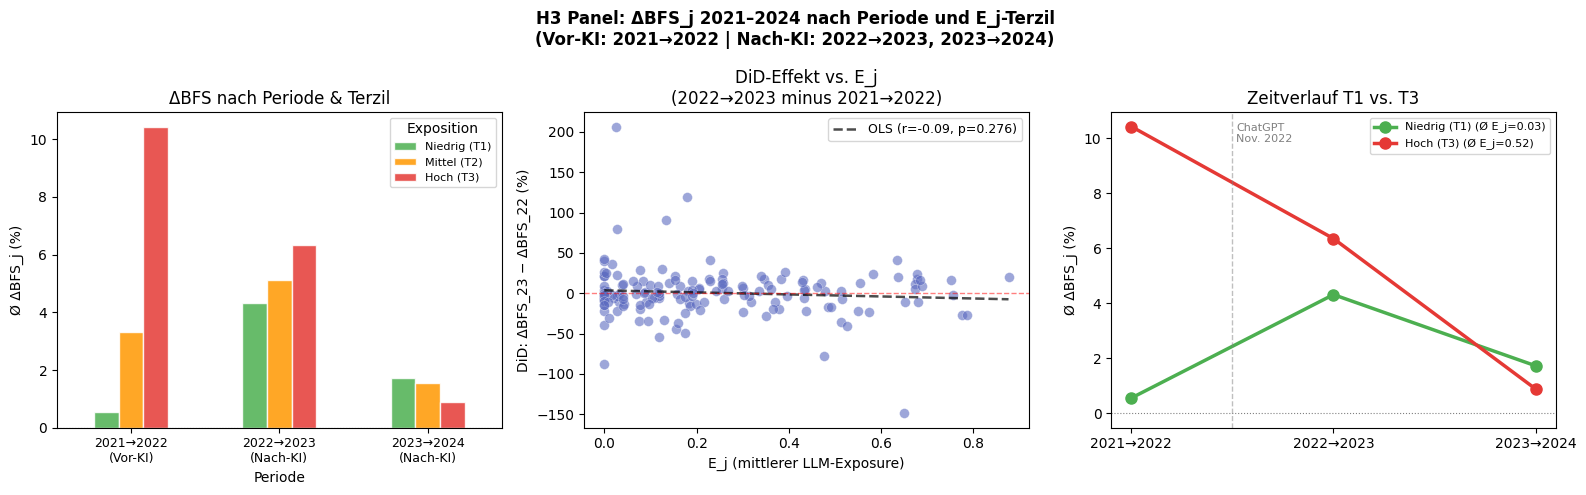

Gespeichert → 6_2_H3_panel.png ✓
Gespeichert → H3_panel_results.csv ✓


In [23]:
# ── Visualisierung Panel-Analyse ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "H3 Panel: ΔBFS_j 2021–2024 nach Periode und E_j-Terzil\n"
    "(Vor-KI: 2021→2022 | Nach-KI: 2022→2023, 2023→2024)",
    fontsize=12, fontweight="bold"
)

# Terzile im Panel-Datensatz
h3_panel["exp_terzil"] = pd.qcut(
    h3_panel["E_j_mean"], q=3,
    labels=["Niedrig (T1)", "Mittel (T2)", "Hoch (T3)"]
)

# Panel 1: ΔBFS nach Periode und Terzil (Balken)
ax = axes[0]
terzil_periode = (
    h3_panel.groupby(["periode", "exp_terzil"], observed=True)["delta_bfs"]
    .mean().unstack()
)
terzil_periode.plot(kind="bar", ax=ax, color=["#4CAF50","#FF9800","#E53935"],
                    alpha=0.85, edgecolor="white")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("Periode")
ax.set_ylabel("Ø ΔBFS_j (%)")
ax.set_title("ΔBFS nach Periode & Terzil")
ax.set_xticklabels(["2021→2022\n(Vor-KI)", "2022→2023\n(Nach-KI)",
                     "2023→2024\n(Nach-KI)"], rotation=0, fontsize=9)
ax.legend(title="Exposition", fontsize=8)

# Panel 2: E_j vs. DiD-Effekt (post − pre)
ax = axes[1]
vor_ki  = h3_panel[h3_panel["periode"]=="2021_2022"].set_index("isco_4digit")["delta_bfs"]
nach_ki = h3_panel[h3_panel["periode"]=="2022_2023"].set_index("isco_4digit")["delta_bfs"]
did_panel = (nach_ki - vor_ki).dropna().reset_index()
did_panel = did_panel.merge(
    h3_panel[["isco_4digit","E_j_mean"]].drop_duplicates(),
    on="isco_4digit", how="left"
)
ax.scatter(did_panel["E_j_mean"], did_panel["delta_bfs"],
           alpha=0.6, s=50, color="#5C6BC0", edgecolors="white", linewidth=0.3)
if len(did_panel) >= 5:
    from scipy import stats as sp_stats
    sl, ic, r_d, p_d, _ = sp_stats.linregress(
        did_panel["E_j_mean"], did_panel["delta_bfs"]
    )
    x_r = np.linspace(did_panel["E_j_mean"].min(), did_panel["E_j_mean"].max(), 100)
    ax.plot(x_r, ic + sl*x_r, "k--", linewidth=1.8, alpha=0.7,
            label=f"OLS (r={r_d:.2f}, p={p_d:.3f})")
    ax.legend(fontsize=9)
ax.axhline(0, color="red", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlabel("E_j (mittlerer LLM-Exposure)")
ax.set_ylabel("DiD: ΔBFS_23 − ΔBFS_22 (%)")
ax.set_title("DiD-Effekt vs. E_j\n(2022→2023 minus 2021→2022)")

# Panel 3: Zeitverlauf Terzil 1 vs. 3
ax = axes[2]
for terzil, color in [("Niedrig (T1)", "#4CAF50"), ("Hoch (T3)", "#E53935")]:
    sub = (
        h3_panel[h3_panel["exp_terzil"]==terzil]
        .groupby("periode")["delta_bfs"].mean()
    )
    ax.plot(["2021→2022","2022→2023","2023→2024"], sub.values,
            "o-", color=color, linewidth=2.5, markersize=8,
            label=f"{terzil} (Ø E_j={h3_panel[h3_panel['exp_terzil']==terzil]['E_j_mean'].mean():.2f})")
ax.axvline(0.5, color="gray", linewidth=1, linestyle="--", alpha=0.5)
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.text(0.52, ax.get_ylim()[1]*0.9, "ChatGPT\nNov. 2022", fontsize=8, color="gray")
ax.set_ylabel("Ø ΔBFS_j (%)")
ax.set_title("Zeitverlauf T1 vs. T3")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "6_2_H3_panel.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gespeichert → 6_2_H3_panel.png ✓")

# Zusammenfassung speichern
panel_summary = pd.DataFrame({
    "metric": ["n_isco_codes", "n_perioden", "beta_DiD", "p_DiD",
               "vor_ki_mean", "nach_ki_mean_22_23", "nach_ki_mean_23_24"],
    "value":  [
        h3_panel["isco_4digit"].nunique(), 3,
        float(beta_panel) if beta_panel is not None else np.nan,
        float(p_panel) if p_panel is not None else np.nan,
        h3_panel[h3_panel["periode"]=="2021_2022"]["delta_bfs"].mean(),
        h3_panel[h3_panel["periode"]=="2022_2023"]["delta_bfs"].mean(),
        h3_panel[h3_panel["periode"]=="2023_2024"]["delta_bfs"].mean(),
    ]
}).round(4)
panel_summary.to_csv(FIGURES / "H3_panel_results.csv", index=False)
print("Gespeichert → H3_panel_results.csv ✓")


---
# Punkt 2: Vor-KI-Basislinie 2019 (Difference-in-Differences)


**Idee:** Vergleich zweier Perioden:
- **Vor-KI-Periode:** ΔBFS 2019–2022 (kein ChatGPT / LLM-Durchbruch)
- **Nach-KI-Periode:** ΔBFS 2022–2024 (nach ChatGPT-Einführung Nov. 2022)

**Frage:** Hat sich der Zusammenhang zwischen E_j und Beschäftigungsveränderung  
nach dem LLM-Durchbruch verändert? Berufe mit hohem Exposure sollten nach 2022  
stärker negative Beschäftigungseffekte zeigen als davor.

**Methodisch:** Difference-in-Differences auf Berufsgruppen-Ebene.


In [24]:
# ── 2019-Daten laden ──────────────────────────────────────────────────────
df_2019 = pd.read_excel(
    REPO_ROOT / "data" / "raw" / "CH_ISCO19.xlsx",
    sheet_name="2019", header=None
)
df_2019["hg"] = pd.to_numeric(df_2019[0], errors="coerce").ffill()
col3_str = df_2019[3].astype(str)
mask_2019 = col3_str.str.match(r"^\d{4}$") & df_2019["hg"].isin([1.0, 2.0, 3.0])
bfs_2019 = df_2019[mask_2019][[3, 6]].copy()
bfs_2019.columns = ["ch_isco_4digit", "employed_2019"]
bfs_2019["ch_isco_4digit"] = bfs_2019["ch_isco_4digit"].astype(str)
bfs_2019["employed_2019"]  = pd.to_numeric(bfs_2019["employed_2019"], errors="coerce")

print(f"2019-Daten: {len(bfs_2019)} Berufsgruppen HG 1–3")
print(f"  davon nicht-NaN: {bfs_2019['employed_2019'].notna().sum()}")


2019-Daten: 271 Berufsgruppen HG 1–3
  davon nicht-NaN: 217


In [25]:
# ── DiD-Datensatz aufbauen ────────────────────────────────────────────────

# Typen angleichen: isco_4digit überall als String
final_isco_bfs["isco_4digit"] = final_isco_bfs["isco_4digit"].astype(str)
bfs_2019["ch_isco_4digit"]    = bfs_2019["ch_isco_4digit"].astype(str)

did_data = (
    final_isco_bfs
    .merge(
        bfs_2019[["ch_isco_4digit", "employed_2019"]]
        .rename(columns={"ch_isco_4digit": "isco_4digit"}),
        on="isco_4digit", how="left"
    )
    .dropna(subset=["employed_2019"])
)

# employed_2022 aus final nachladen
final["isco_4digit"] = final["isco_4digit"].astype(str)
emp_2022 = (
    final[["isco_4digit", "employed_2022"]]
    .dropna(subset=["employed_2022"])
    .groupby("isco_4digit")["employed_2022"]
    .first()
    .reset_index()
)
did_data = did_data.merge(emp_2022, on="isco_4digit", how="left")

# Vor-KI-Periode: 2019 → 2022
did_data["delta_bfs_pre"] = (
    (did_data["employed_2022"] - did_data["employed_2019"])
    / did_data["employed_2019"] * 100
)

# Nach-KI-Periode: 2022 → 2024 (= delta_bfs bereits vorhanden)
did_data = did_data.rename(columns={"delta_bfs": "delta_bfs_post"})

# Differenz der Differenzen
did_data["did"] = did_data["delta_bfs_post"] - did_data["delta_bfs_pre"]

# Ausreisser in beiden Perioden entfernen
for col in ["delta_bfs_pre", "delta_bfs_post"]:
    Q1, Q3 = did_data[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    did_data = did_data[did_data[col].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)]

print(f"DiD-Sample: {len(did_data)} Berufsgruppen (beide Perioden, ohne Ausreisser)")
print()
print("=== Deskriptive Übersicht ===")
desc = did_data[["delta_bfs_pre", "delta_bfs_post", "did"]].describe().round(2)
desc.index.name = ""
print(desc.to_string())
print()
print(f"  Vor-KI  (2019–2022): Ø {did_data['delta_bfs_pre'].mean():.1f}%")
print(f"  Nach-KI (2022–2024): Ø {did_data['delta_bfs_post'].mean():.1f}%")
print(f"  DiD (Differenz):     Ø {did_data['did'].mean():.1f}%")

DiD-Sample: 139 Berufsgruppen (beide Perioden, ohne Ausreisser)

=== Deskriptive Übersicht ===
       delta_bfs_pre  delta_bfs_post     did
                                            
count         139.00          139.00  139.00
mean           10.65            3.31   -7.35
std            18.75           11.41   23.43
min           -31.90          -25.66  -68.74
25%            -2.30           -3.41  -22.42
50%            10.07            2.17   -6.76
75%            23.08           10.75    8.73
max            60.76           34.68   42.68

  Vor-KI  (2019–2022): Ø 10.7%
  Nach-KI (2022–2024): Ø 3.3%
  DiD (Differenz):     Ø -7.3%


In [26]:
# ── DiD-Regression: Hat E_j nach 2022 einen stärkeren Effekt? ────────────
did_main = did_data[~did_data["is_outlier"]].copy()

# Modell 1: Bivariat
model_did1 = smf.ols("did ~ E_j_mean", data=did_main).fit(cov_type="HC3")

# Modell 2: Mit Sektor
did_main["sektor"] = did_main["isco_4digit"].apply(assign_sector)
valid_s_did = did_main["sektor"].value_counts()[lambda x: x >= 3].index.tolist()
did_main_s  = did_main[did_main["sektor"].isin(valid_s_did)].copy()

# Referenzsektor = häufigster Sektor im gefilterten Sample
ref_sektor = did_main_s["sektor"].value_counts().idxmax()
print(f"Referenzsektor: {ref_sektor}")

if len(did_main_s) >= 10:
    model_did2 = smf.ols(
        f"did ~ E_j_mean + C(sektor, Treatment('{ref_sektor}'))",
        data=did_main_s
    ).fit(cov_type="HC3")
else:
    model_did2 = model_did1

print("=== DiD-Regression: Veränderung des E_j-Effekts nach 2022 ===")
print(f"N = {int(model_did1.nobs)} Berufsgruppen (ohne Ausreisser)")
print()
print("Modell 1 – Bivariat:")
print(model_did1.summary2().tables[1].round(3))
print(f"R²={model_did1.rsquared:.3f} | p(E_j)={model_did1.pvalues['E_j_mean']:.4f}")
print()
if model_did2 is not model_did1:
    print(f"Modell 2 – Mit Sektor-Kontrolle (Referenz: {ref_sektor}):")
    print(model_did2.summary2().tables[1].round(3))
    print(f"R²={model_did2.rsquared:.3f} | p(E_j)={model_did2.pvalues['E_j_mean']:.4f}")

Referenzsektor: Ingenieurwesen & Naturwiss.
=== DiD-Regression: Veränderung des E_j-Effekts nach 2022 ===
N = 139 Berufsgruppen (ohne Ausreisser)

Modell 1 – Bivariat:
           Coef.  Std.Err.      z  P>|z|  [0.025  0.975]
Intercept -5.541     3.145 -1.762  0.078 -11.705   0.622
E_j_mean  -7.768     9.020 -0.861  0.389 -25.447   9.911
R²=0.005 | p(E_j)=0.3891

Modell 2 – Mit Sektor-Kontrolle (Referenz: Ingenieurwesen & Naturwiss.):
                                                     Coef.  Std.Err.      z  \
Intercept                                           -7.821     5.227 -1.496   
C(sektor, Treatment('Ingenieurwesen & Naturwiss...   7.598     5.596  1.358   
C(sektor, Treatment('Ingenieurwesen & Naturwiss...  11.412    11.985  0.952   
C(sektor, Treatment('Ingenieurwesen & Naturwiss...   0.932     5.810  0.160   
C(sektor, Treatment('Ingenieurwesen & Naturwiss...  -7.470     8.664 -0.862   
C(sektor, Treatment('Ingenieurwesen & Naturwiss...   0.279     6.629  0.042   
E_j_mean 

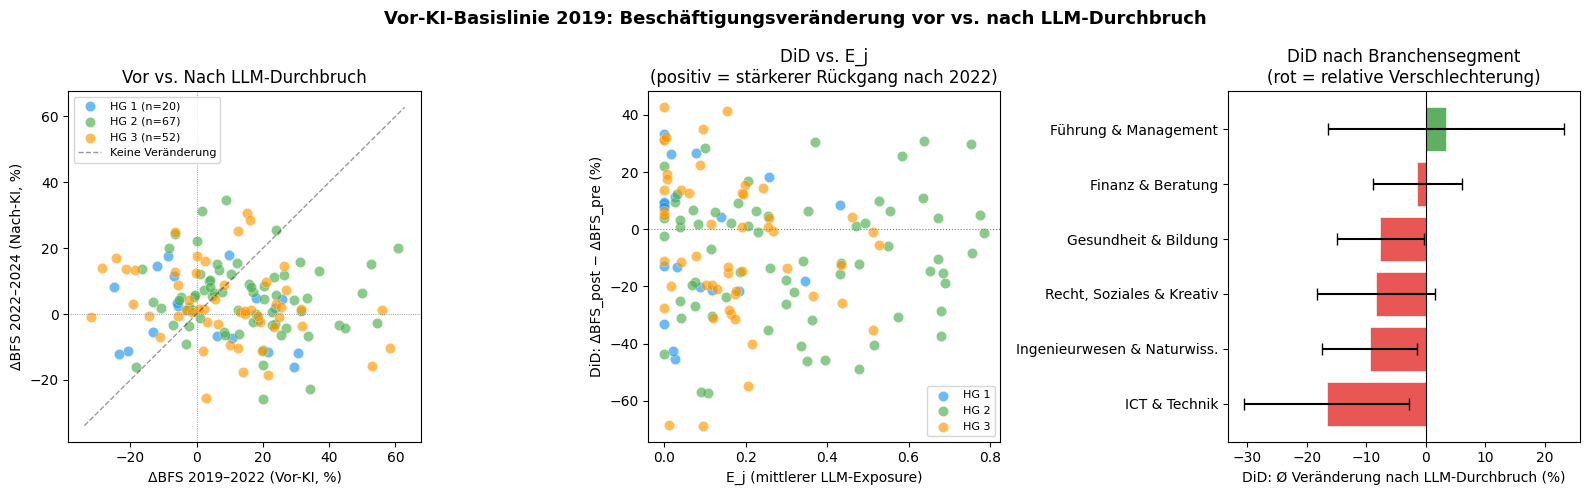

Gespeichert → output/EDA/6_2_did_analysis.png ✓


In [27]:
# ── DiD-Visualisierung ────────────────────────────────────────════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Vor-KI-Basislinie 2019: Beschäftigungsveränderung vor vs. nach LLM-Durchbruch",
    fontsize=13, fontweight="bold"
)

colors_did = {1: "#2196F3", 2: "#4CAF50", 3: "#FF9800"}

# Panel 1: Vor vs. Nach Scatter
ax = axes[0]
for hg in sorted(did_main["main_group"].dropna().unique()):
    s = did_main[did_main["main_group"] == hg]
    ax.scatter(s["delta_bfs_pre"], s["delta_bfs_post"],
               color=colors_did.get(int(hg), "gray"), alpha=0.65, s=55,
               label=f"HG {int(hg)} (n={len(s)})", edgecolors="white", linewidth=0.3)
lim_min = min(did_main["delta_bfs_pre"].min(), did_main["delta_bfs_post"].min()) - 2
lim_max = max(did_main["delta_bfs_pre"].max(), did_main["delta_bfs_post"].max()) + 2
ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", linewidth=1, alpha=0.4, label="Keine Veränderung")
ax.set_xlabel("ΔBFS 2019–2022 (Vor-KI, %)")
ax.set_ylabel("ΔBFS 2022–2024 (Nach-KI, %)")
ax.set_title("Vor vs. Nach LLM-Durchbruch")
ax.legend(fontsize=8)
ax.axhline(0, color="gray", linewidth=0.6, linestyle=":")
ax.axvline(0, color="gray", linewidth=0.6, linestyle=":")

# Panel 2: DiD vs. E_j
ax = axes[1]
for hg in sorted(did_main["main_group"].dropna().unique()):
    s = did_main[did_main["main_group"] == hg]
    ax.scatter(s["E_j_mean"], s["did"],
               color=colors_did.get(int(hg), "gray"), alpha=0.65, s=55,
               label=f"HG {int(hg)}", edgecolors="white", linewidth=0.3)
if model_did1.pvalues["E_j_mean"] < 0.2:
    x_d = np.linspace(did_main["E_j_mean"].min(), did_main["E_j_mean"].max(), 100)
    y_d = model_did1.params["Intercept"] + model_did1.params["E_j_mean"] * x_d
    ax.plot(x_d, y_d, "k--", linewidth=1.8, alpha=0.65,
            label=f"OLS (β={model_did1.params['E_j_mean']:.2f}, p={model_did1.pvalues['E_j_mean']:.3f})")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("E_j (mittlerer LLM-Exposure)")
ax.set_ylabel("DiD: ΔBFS_post − ΔBFS_pre (%)")
ax.set_title("DiD vs. E_j\n(positiv = stärkerer Rückgang nach 2022)")
ax.legend(fontsize=8)

# Panel 3: DiD nach Sektor
ax = axes[2]
did_sektor = (
    did_main.assign(sektor=lambda x: x["isco_4digit"].apply(assign_sector))
    .groupby("sektor")["did"]
    .agg(["mean", "sem", "count"])
    .reset_index()
    .query("count >= 3")
    .sort_values("mean", ascending=True)
)
bar_colors_did = ["#E53935" if m < 0 else "#43A047" for m in did_sektor["mean"]]
ax.barh(did_sektor["sektor"], did_sektor["mean"],
        xerr=did_sektor["sem"] * 1.96,
        color=bar_colors_did, alpha=0.85, capsize=4,
        edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("DiD: Ø Veränderung nach LLM-Durchbruch (%)")
ax.set_title("DiD nach Branchensegment\n(rot = relative Verschlechterung)")

plt.tight_layout()
plt.savefig(FIGURES / "6_2_did_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gespeichert → output/EDA/6_2_did_analysis.png ✓")


In [28]:
# ── DiD-Ergebnisse speichern ──────────────────────────────────────────────
did_results = pd.DataFrame({
    "metric": ["n_sample", "delta_bfs_pre_mean", "delta_bfs_post_mean",
                "did_mean", "beta_Ej_did", "p_Ej_did", "r2_did"],
    "value":  [len(did_main),
                did_main["delta_bfs_pre"].mean(),
                did_main["delta_bfs_post"].mean(),
                did_main["did"].mean(),
                model_did1.params["E_j_mean"],
                model_did1.pvalues["E_j_mean"],
                model_did1.rsquared]
}).round(4)

did_results.to_csv(FIGURES / "DiD_results.csv", index=False)

# DiD-Datensatz für Robustheitscheck
did_data.to_csv(FIGURES / "did_dataset.csv", index=False)

print("Gespeichert → data/output/Hypothesen/DiD_results.csv ✓")
print("Gespeichert → data/processed/analysis_prep/did_dataset.csv ✓")
print()
print("=== Interpretation ===")
beta = model_did1.params["E_j_mean"]
p    = model_did1.pvalues["E_j_mean"]
if p < 0.05 and beta > 0:
    print(f"✓ Signifikant positives β={beta:.3f}: Berufe mit hohem E_j zeigen nach 2022")
    print("  relativ stärkere Beschäftigungsrückgänge — konsistent mit LLM-Displacement-Hypothese.")
elif p < 0.05 and beta < 0:
    print(f"~ Signifikant negatives β={beta:.3f}: Berufe mit hohem E_j entwickeln sich")
    print("  nach 2022 besser — konsistent mit Augmentations-Hypothese.")
else:
    print(f"~ Nicht signifikantes β={beta:.3f} (p={p:.3f}): Kein messbarer LLM-spezifischer")
    print("  Trendwechsel in 2022–2024 — repliziert Humlum & Vestergaard (2025).")
    print("  Interpretation: Adoptionslücke oder zu kurzer Beobachtungszeitraum.")


Gespeichert → data/output/Hypothesen/DiD_results.csv ✓
Gespeichert → data/processed/analysis_prep/did_dataset.csv ✓

=== Interpretation ===
~ Nicht signifikantes β=-7.768 (p=0.389): Kein messbarer LLM-spezifischer
  Trendwechsel in 2022–2024 — repliziert Humlum & Vestergaard (2025).
  Interpretation: Adoptionslücke oder zu kurzer Beobachtungszeitraum.


---
## H3 Erweiterung – Sektor als Kontrollvariable


In [29]:
# ── H3 erweitert: Sektor als Kontrollvariable ─────────────────────────────
h3_sektor = final_isco_bfs[final_isco_bfs["sektor"].isin(valid_sektoren)].copy()
h3_sektor_main = h3_sektor[~h3_sektor["is_outlier"]].copy()

# Referenzsektor = häufigster Sektor im gefilterten Sample
ref_sektor_h3 = h3_sektor_main["sektor"].value_counts().idxmax()
print(f"Referenzsektor H3: {ref_sektor_h3}")

if len(h3_sektor_main) >= 10:
    model_sektor = smf.ols(
        f"delta_bfs ~ E_j_mean + C(sektor, Treatment('{ref_sektor_h3}'))",
        data=h3_sektor_main
    ).fit(cov_type="HC3")
    print("=== H3 mit Sektor-Kontrolle ===")
    print(model_sektor.summary2().tables[1].round(3))
    print(f"R²={model_sektor.rsquared:.3f} | Adj.R²={model_sektor.rsquared_adj:.3f} | N={int(model_sektor.nobs)}")
else:
    print(f"⚠ Zu wenige Beobachtungen für sektorale Regression (n={len(h3_sektor_main)})")

Referenzsektor H3: Ingenieurwesen & Naturwiss.
=== H3 mit Sektor-Kontrolle ===
                                                    Coef.  Std.Err.      z  \
Intercept                                           2.670     2.448  1.091   
C(sektor, Treatment('Ingenieurwesen & Naturwiss... -0.383     3.022 -0.127   
C(sektor, Treatment('Ingenieurwesen & Naturwiss... -3.348     4.688 -0.714   
C(sektor, Treatment('Ingenieurwesen & Naturwiss... -0.022     3.133 -0.007   
C(sektor, Treatment('Ingenieurwesen & Naturwiss... -2.534     3.669 -0.691   
C(sektor, Treatment('Ingenieurwesen & Naturwiss... -1.740     3.521 -0.494   
E_j_mean                                            9.028     4.875  1.852   

                                                    P>|z|  [0.025  0.975]  
Intercept                                           0.275  -2.127   7.468  
C(sektor, Treatment('Ingenieurwesen & Naturwiss...  0.899  -6.306   5.539  
C(sektor, Treatment('Ingenieurwesen & Naturwiss...  0.475 -12.535   

In [31]:
# ── Ergänzende Kennzahlen für Kapitel 6 & 7 ─────────────────────────────
# In sich geschlossen: alle benötigten Variablen werden hier neu aufgebaut.
# Kann auch als eigenständiges Notebook ausgeführt werden.

import pandas as pd
import numpy as np
from scipy import stats as sp_stats

# ── Daten laden ───────────────────────────────────────────────────────────
final_raw   = pd.read_csv(ANALYSIS / "final_sample.csv")
h2_imp      = pd.read_csv(FIGURES  / "H2_feature_importance.csv")

# ── ISCO-Aggregation (analog zu Cell 4) ──────────────────────────────────
fi = (
    final_raw.groupby("isco_4digit")
    .agg(
        E_j_mean   = ("E_j",       "mean"),
        E_sub_mean = ("E_sub_j",   "mean"),
        E_aug_mean = ("E_aug_j",   "mean"),
        s_ij_mean  = ("s_ij",      "mean"),
        delta_bfs  = ("delta_bfs", "first"),
        is_outlier = ("is_outlier","first"),
        main_group = ("main_group","first"),
        n_onet     = ("soc_code",  "count"),
    )
    .reset_index()
)
fi["is_outlier"] = fi["is_outlier"].astype(str).isin(["True","1","1.0"])
fi_bfs   = fi.dropna(subset=["delta_bfs"]).copy()
fi_main  = fi_bfs[~fi_bfs["is_outlier"]].copy()

# ════════════════════════════════════════════════════════════════════════
# 1. TUKEY-HSD (alle drei Paare) auf O*NET-Ebene
# ════════════════════════════════════════════════════════════════════════
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog  = final_raw["E_j"].dropna(),
    groups = final_raw.loc[final_raw["E_j"].notna(), "main_group"],
    alpha  = 0.05
)
tukey_df = pd.DataFrame(
    data    = tukey._results_table.data[1:],
    columns = tukey._results_table.data[0]
)
# Cohen's d je Paar ergänzen
hg_labels = {1: "HG1", 2: "HG2", 3: "HG3"}
cohen_d = []
for _, row in tukey_df.iterrows():
    g1 = final_raw[final_raw["main_group"] == int(row["group1"])]["E_j"].dropna()
    g2 = final_raw[final_raw["main_group"] == int(row["group2"])]["E_j"].dropna()
    pooled_std = np.sqrt((g1.var() + g2.var()) / 2)
    d = abs(g1.mean() - g2.mean()) / pooled_std if pooled_std > 0 else np.nan
    cohen_d.append(round(d, 3))
tukey_df["cohen_d"] = cohen_d
tukey_df.to_csv(FIGURES / "H1_tukey_results.csv", index=False)
print("=== Tukey-HSD Ergebnisse ===")
print(tukey_df.to_string(index=False))

# ════════════════════════════════════════════════════════════════════════
# 2. s_ij-DOMINANZ: Varianzanteil von s_ij an E_j
# ════════════════════════════════════════════════════════════════════════
r_sij_Ej, p_sij_Ej = sp_stats.pearsonr(final_raw["s_ij"], final_raw["E_j"])

# Partieller Korrelationscheck: E_j ~ s_ij nach Kontrolle von w_ij-Summe
# Proxy: mittlerer w_ij-Wert je Beruf (ergibt sich aus E_j / (mu * s_ij))
# Einfache Regression E_j ~ s_ij
slope, intercept, r_lin, p_lin, se = sp_stats.linregress(final_raw["s_ij"], final_raw["E_j"])

sij_df = pd.DataFrame({
    "metric": [
        "pearson_r_sij_Ej",
        "r2_sij_Ej",
        "p_sij_Ej",
        "OLS_slope",
        "OLS_intercept",
        "n"
    ],
    "value": [
        round(r_sij_Ej, 4),
        round(r_sij_Ej**2, 4),
        round(p_sij_Ej, 6),
        round(slope, 4),
        round(intercept, 4),
        len(final_raw)
    ]
})
sij_df.to_csv(FIGURES / "sij_dominanz.csv", index=False)
print()
print("=== s_ij-Dominanz ===")
print(f"Pearson r(s_ij, E_j) = {r_sij_Ej:.4f} (p={p_sij_Ej:.6f})")
print(f"R² = {r_sij_Ej**2:.4f} → s_ij erklärt {r_sij_Ej**2*100:.1f}% der Varianz in E_j")
print(f"Methodische Limitation: E_j = Σ μ_i · w_ij · s_ij → s_ij ist multiplikativ enthalten")

# ════════════════════════════════════════════════════════════════════════
# 3. TERZIL-ANALYSE mit t-Test (vollständig neu berechnet)
# ════════════════════════════════════════════════════════════════════════
fi_bfs["exp_terzil"] = pd.qcut(
    fi_bfs["E_j_mean"], q=3,
    labels=["T1 (Niedrig)", "T2 (Mittel)", "T3 (Hoch)"]
)

terzil_stats = (
    fi_bfs.groupby("exp_terzil", observed=True)
    .agg(
        n             = ("isco_4digit", "count"),
        E_j_mean      = ("E_j_mean",    "mean"),
        E_j_min       = ("E_j_mean",    "min"),
        E_j_max       = ("E_j_mean",    "max"),
        delta_bfs_mean = ("delta_bfs",  "mean"),
        delta_bfs_std  = ("delta_bfs",  "std"),
        delta_bfs_median = ("delta_bfs","median"),
    )
    .round(3)
    .reset_index()
)

t1_vals = fi_bfs[fi_bfs["exp_terzil"] == "T1 (Niedrig)"]["delta_bfs"].dropna()
t3_vals = fi_bfs[fi_bfs["exp_terzil"] == "T3 (Hoch)"  ]["delta_bfs"].dropna()
t_stat, t_p = sp_stats.ttest_ind(t1_vals, t3_vals, equal_var=False)

# Cohen's d T1 vs T3
pooled = np.sqrt((t1_vals.var() + t3_vals.var()) / 2)
d_t1t3 = abs(t3_vals.mean() - t1_vals.mean()) / pooled

terzil_ttest = pd.DataFrame({
    "metric": [
        "T1_n", "T2_n", "T3_n",
        "T1_E_j_mean", "T2_E_j_mean", "T3_E_j_mean",
        "T1_delta_bfs_mean", "T2_delta_bfs_mean", "T3_delta_bfs_mean",
        "T1_delta_bfs_std",  "T3_delta_bfs_std",
        "welch_t_stat", "welch_p", "cohen_d_T1_T3"
    ],
    "value": [
        int(terzil_stats.loc[terzil_stats["exp_terzil"]=="T1 (Niedrig)","n"].values[0]),
        int(terzil_stats.loc[terzil_stats["exp_terzil"]=="T2 (Mittel)","n"].values[0]),
        int(terzil_stats.loc[terzil_stats["exp_terzil"]=="T3 (Hoch)","n"].values[0]),
        round(float(terzil_stats.loc[terzil_stats["exp_terzil"]=="T1 (Niedrig)","E_j_mean"].values[0]), 3),
        round(float(terzil_stats.loc[terzil_stats["exp_terzil"]=="T2 (Mittel)","E_j_mean"].values[0]), 3),
        round(float(terzil_stats.loc[terzil_stats["exp_terzil"]=="T3 (Hoch)","E_j_mean"].values[0]), 3),
        round(float(t1_vals.mean()), 3),
        round(float(fi_bfs[fi_bfs["exp_terzil"]=="T2 (Mittel)"]["delta_bfs"].mean()), 3),
        round(float(t3_vals.mean()), 3),
        round(float(t1_vals.std()), 3),
        round(float(t3_vals.std()), 3),
        round(float(t_stat), 4),
        round(float(t_p), 4),
        round(float(d_t1t3), 3),
    ]
})
terzil_ttest.to_csv(FIGURES / "H3_terzil_ttest.csv", index=False)

print()
print("=== Terzil-Analyse ΔBFS_j ===")
print(terzil_stats.to_string(index=False))
print(f"Welch t-Test T1 vs T3: t={t_stat:.3f}, p={t_p:.4f}")
print(f"Cohen's d = {d_t1t3:.3f} ({'klein' if d_t1t3<0.2 else 'mittel' if d_t1t3<0.5 else 'gross'})")
print(f"Interpretation: {'Kein signifikanter Unterschied' if t_p >= 0.05 else 'Signifikanter Unterschied'} (α=0.05)")

# ════════════════════════════════════════════════════════════════════════
# 4. ZUSAMMENFASSUNG ALLER LÜCKEN-KPIs
# ════════════════════════════════════════════════════════════════════════
summary = pd.DataFrame({
    "kennzahl": [
        "Tukey HG1-HG2 reject",
        "Tukey HG1-HG3 reject",
        "Tukey HG2-HG3 reject",
        "Tukey HG1-HG2 cohen_d",
        "Tukey HG2-HG3 cohen_d",
        "r_sij_Ej",
        "r2_sij_Ej_pct",
        "Terzil_T1_delta_bfs",
        "Terzil_T3_delta_bfs",
        "Terzil_welch_p",
        "Terzil_cohen_d",
    ],
    "wert": [
        str(tukey_df.iloc[0]["reject"]),
        str(tukey_df.iloc[1]["reject"]),
        str(tukey_df.iloc[2]["reject"]),
        round(float(tukey_df.iloc[0]["cohen_d"]), 3),
        round(float(tukey_df.iloc[2]["cohen_d"]), 3),
        round(r_sij_Ej, 4),
        round(r_sij_Ej**2 * 100, 1),
        round(float(t1_vals.mean()), 2),
        round(float(t3_vals.mean()), 2),
        round(float(t_p), 4),
        round(float(d_t1t3), 3),
    ]
})
summary.to_csv(FIGURES / "kap6_ergaenzende_kennzahlen.csv", index=False)
print()
print("=== Gespeicherte Dateien ===")
for f in ["H1_tukey_results.csv", "sij_dominanz.csv",
          "H3_terzil_ttest.csv", "kap6_ergaenzende_kennzahlen.csv"]:
    print(f"  ✓ data/output/Hypothesen/{f}")


=== Tukey-HSD Ergebnisse ===
 group1  group2  meandiff  p-adj   lower   upper  reject  cohen_d
      1       2    0.2353 0.0000  0.1618  0.3087    True    1.119
      1       3    0.0938 0.0107  0.0179  0.1697    True    0.555
      2       3   -0.1415 0.0000 -0.1887 -0.0942    True    0.626

=== s_ij-Dominanz ===
Pearson r(s_ij, E_j) = 0.9847 (p=0.000000)
R² = 0.9697 → s_ij erklärt 97.0% der Varianz in E_j
Methodische Limitation: E_j = Σ μ_i · w_ij · s_ij → s_ij ist multiplikativ enthalten

=== Terzil-Analyse ΔBFS_j ===
  exp_terzil  n  E_j_mean  E_j_min  E_j_max  delta_bfs_mean  delta_bfs_std  delta_bfs_median
T1 (Niedrig) 52     0.027    0.000    0.090           3.656         15.853             3.651
 T2 (Mittel) 52     0.183    0.095    0.301           5.978         22.332             1.593
   T3 (Hoch) 52     0.517    0.302    0.876           6.681         17.137             5.552
Welch t-Test T1 vs T3: t=-0.934, p=0.3523
Cohen's d = 0.183 (klein)
Interpretation: Kein signifikante